# Balancing DQC Agent and Flow

## Set-up

In [2]:
# PATH = '../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c/'
PATH = '../../scratch/dqc-reproduce/sd100001s_33415523.0.33415522.1.20260415_020458/'

CKPT_NUM = 1000000

In [3]:
import json
import os

import numpy as np

from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset, CGCDataset
from utils.flax_utils import restore_agent

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [4]:
flags_path = os.path.join(PATH, 'flags.json')
with open(flags_path, 'r') as f:
    saved_flags = json.load(f)

agent_config = saved_flags['agent']
dataset_class_name = agent_config.get('dataset_class', 'GCDataset')
dataset_class = {
    'GCDataset': GCDataset,
    'HGCDataset': HGCDataset,
    'CGCDataset': CGCDataset,
}[dataset_class_name]

# dataset_path = os.path.join(PATH, 'data-100000.npz')
# dataset_npz = np.load('../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz')
# train_dataset = dataset_class(Dataset.create(**dict(dataset_npz)), config=agent_config)

seed = saved_flags.get('seed', 0)


## Flow set-up

In [5]:
saved_flags['env_name']

'humanoidmaze-giant-navigate-oraclerep-v0'

In [6]:
config = dict(
    env_name='humanoidmaze-giant-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=100000,
    log_interval=100,
    seed=0,
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=25,
    discount=0.995,
    flow_steps=10,
    backup_horizon=25,
    goal_conditioned=False,
)

config

{'env_name': 'humanoidmaze-giant-navigate-v0',
 'dataset_path': '../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'actions_key': 'low_actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'batch_size': 256,
 'num_train_steps': 100000,
 'log_interval': 100,
 'seed': 0,
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'subgoal_steps': 25,
 'discount': 0.995,
 'flow_steps': 10,
 'backup_horizon': 25,
 'goal_conditioned': False}

In [7]:
from wrappers.datafuncs_utils import make_env_and_datasets

env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = CGCDataset(base_train_dataset, config=config)

In [8]:
agent_config['train_goal_proposer'] = False

In [9]:
example_batch = train_dataset.sample(1)

first_agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
first_agent = restore_agent(first_agent, PATH, CKPT_NUM)

print(f'Restored first_agent from checkpoint {CKPT_NUM}')

Restored from ../../scratch/dqc-reproduce/sd100001s_33415523.0.33415522.1.20260415_020458//params_1000000.pkl
Restored first_agent from checkpoint 1000000


In [10]:
dqc_agent = first_agent

In [11]:
from tqdm import tqdm

all_cells = {}

for ob in tqdm(train_dataset.dataset['observations']):
    key = (np.floor(ob[0]), np.floor(ob[1]))
    if key in all_cells:
        all_cells[key] += 1
    else:
        all_cells[key] = 1

all_cell_points = np.asarray(list(all_cells.keys()))

100%|██████████| 4000000/4000000 [00:21<00:00, 184235.21it/s]


In [12]:
from utils.networks import ActorVectorField
from __future__ import annotations

from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from utils.datasets import GCDataset
from utils.flax_utils import TrainState, nonpytree_field
from utils.networks import ActorVectorField, MLP
from wrappers.datafuncs_utils import make_env_and_datasets


In [13]:
class GCFlowGoalProposerAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def flow_loss(self, batch, grad_params=None, rng=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']] if self.config['goal_conditioned'] else None
        target_actions = batch[self.config['actions_key']]

        batch_size, action_dim = target_actions.shape
        rng = self.rng if rng is None else rng
        x_rng, t_rng = jax.random.split(rng)

        x_0 = jax.random.normal(x_rng, (batch_size, action_dim))
        t = jax.random.uniform(t_rng, (batch_size, 1))
        x_t = (1.0 - t) * x_0 + t * target_actions
        vel = target_actions - x_0

        pred_vel = self.network(
            observations,
            goals=goals,
            actions=x_t,
            times=t,
            params=grad_params,
        )
        loss = jnp.mean(jnp.square(pred_vel - vel))
        mae = jnp.mean(jnp.abs(pred_vel - vel))
        return loss, {
            'flow_loss': loss,
            'velocity_mae': mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.flow_loss(batch, grad_params, rng=rng)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals, rng):
        single_example = observations.ndim == 1
        if not self.config['goal_conditioned']:
            goals = None
        if single_example:
            observations = observations[None, ...]
            if goals is not None:
                goals = goals[None, ...]

        x = jax.random.normal(rng, (observations.shape[0], self.config['action_dim']))

        for i in range(self.config['flow_steps']):
            t = jnp.full((observations.shape[0], 1), i / self.config['flow_steps'])
            vels = self.network(observations, goals=goals, actions=x, times=t)
            x = x + vels / self.config['flow_steps']

        return x[0] if single_example else x

    @classmethod
    def create(cls, example_batch, config):
        config = dict(config)
        config.setdefault('goal_conditioned', True)
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = ActorVectorField(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        init_goals = example_batch[config['goal_key']] if config['goal_conditioned'] else None
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            goals=init_goals,
            actions=example_batch[config['actions_key']],
            times=example_batch[config['actions_key']][..., :1],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        config['action_dim'] = action_dim
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))

In [14]:
example_batch = train_dataset.sample(1)
flow_agent = GCFlowGoalProposerAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, flow_agent.network.params)

flow_loss_history = []
velocity_mae_history = []

for step in range(1, config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    flow_agent, info = flow_agent.update(batch)

    flow_loss_history.append(float(info['flow_loss']))
    velocity_mae_history.append(float(info['velocity_mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} flow_loss={flow_loss_history[-1]:.6f} velocity_mae={velocity_mae_history[-1]:.6f}"
        )

step=00001 flow_loss=634.635986 velocity_mae=20.781391
step=00100 flow_loss=151.476013 velocity_mae=9.320789
step=00200 flow_loss=74.210899 velocity_mae=6.313640
step=00300 flow_loss=31.666491 velocity_mae=3.701612
step=00400 flow_loss=16.327335 velocity_mae=2.671430
step=00500 flow_loss=8.664313 velocity_mae=2.117203
step=00600 flow_loss=5.288741 velocity_mae=1.666485
step=00700 flow_loss=6.426572 velocity_mae=1.771222
step=00800 flow_loss=4.500892 velocity_mae=1.626246
step=00900 flow_loss=3.447679 velocity_mae=1.386400
step=01000 flow_loss=2.929305 velocity_mae=1.347220
step=01100 flow_loss=3.235472 velocity_mae=1.422128
step=01200 flow_loss=2.650349 velocity_mae=1.245294
step=01300 flow_loss=2.569818 velocity_mae=1.276091
step=01400 flow_loss=2.833535 velocity_mae=1.317743
step=01500 flow_loss=2.150898 velocity_mae=1.174985
step=01600 flow_loss=2.453425 velocity_mae=1.216439
step=01700 flow_loss=2.134043 velocity_mae=1.140418
step=01800 flow_loss=2.293947 velocity_mae=1.193466
step

100%|██████████| 200/200 [00:02<00:00, 74.06it/s] 


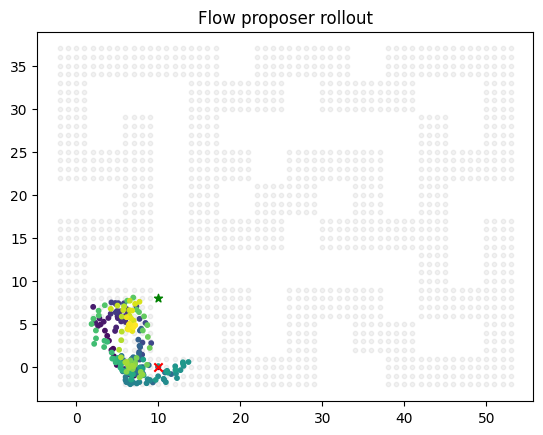

In [15]:
replay_buffer = []
# ob = np.asarray([20.0, 25.0])
# ob = np.asarray([0.0, 8.0])
# ob = np.asarray([5.0, 0.0])
# goal = np.asarray([20.0, 0.0])

# ob = np.asarray([15.0, 20.0])
ob = np.asarray([10.0, 0.0])
goal = np.asarray([20.0, 0.0])
goal = np.asarray([10.0, 8.0])
rng = jax.random.PRNGKey(config['seed'])

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.005:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

## Utilities

In [16]:
def sample_n(ob, goal, n, sample_rng, agent=flow_agent):
    ob_xy = ob[:2]
    obs = np.repeat(ob_xy[None], n, axis=0)
    goals = np.repeat(goal[None], n, axis=0)

    return flow_agent.sample_actions(obs, goals, sample_rng)

In [17]:
def value_xy(ob, subgoals, goal, agent=dqc_agent):
    assert subgoals.ndim > 1, 'did not provide multiple subgoals'
    subgoal_obs = np.repeat(ob[None], len(subgoals), axis=0)
    subgoal_obs[..., :2] = subgoals
    goals = np.repeat(goal[None], len(subgoals), axis=0)

    vs = agent.network.select('value')(subgoal_obs, goals)
    return vs

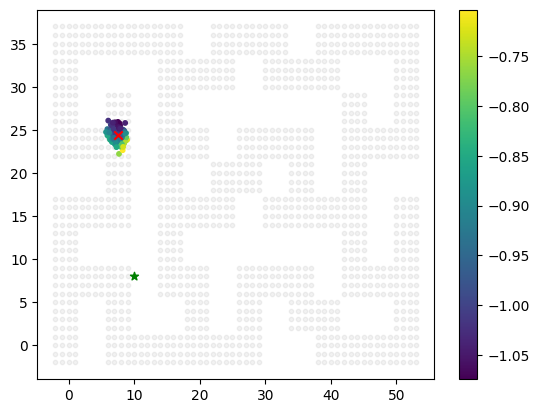

In [18]:
ob = train_dataset.dataset['observations'][12000]

sample_rng, rng = jax.random.split(rng)
subgoals = sample_n(ob, goal, 128, sample_rng)
vs = value_xy(ob, subgoals, goal)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], c=vs, cmap='viridis', s=10)
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

/tmp/ipykernel_3952337/531988712.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(c)


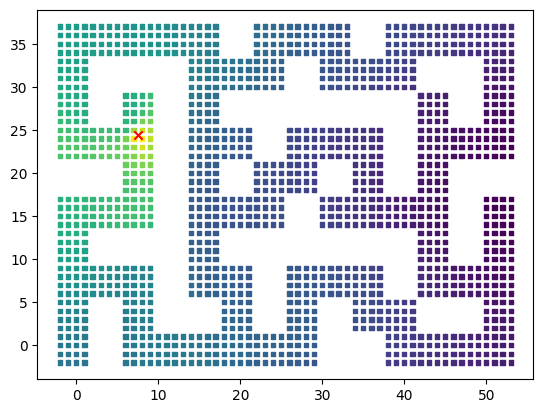

In [19]:
all_obs = np.repeat(ob[None], len(all_cell_points), axis=0)
ob_to_subgoal = dqc_agent.network.select('value')(all_obs, all_cell_points)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=1.0, marker='s', c=ob_to_subgoal)
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
# plt.scatter(x=goal[0], y=[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

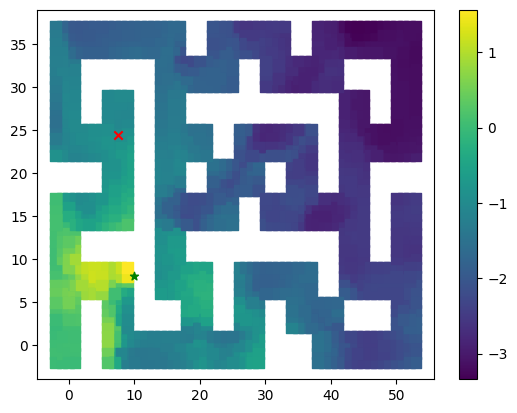

In [20]:
# all_obs = np.repeat(ob[None], len(all_cell_points), axis=0)
# ob = train_dataset.dataset['observations'][12000]
subgoal_to_goal = value_xy(ob, all_cell_points, goal)
# subgoal_obs = np.repeat(ob[None], len(all_cell_points), axis=0)
# # subgoal_obs[..., :2] = all_cell_points

# for i in range(len(all_cell_points)):
#     subgoal_obs[i, 0] = all_cell_points[i][0]
#     subgoal_obs[i, 1] = all_cell_points[i][1]

# goals = np.repeat(goal[None], len(all_cell_points), axis=0)
# print(goal)

# subgoal_to_goal = dqc_agent.network.select('value')(subgoal_obs, goals)

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=subgoal_to_goal)
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

In [21]:
dqc_agent.config['discount']

0.999

In [22]:
def sigmoid(x):
    x = np.asarray(x)
    return np.where(
        x >= 0,
        1 / (1 + np.exp(-x)),
        np.exp(x) / (1 + np.exp(x)),
    )


In [23]:
def dynamical_distance(ob, subgoals, goal, agent=dqc_agent):

    all_obs = np.repeat(ob[None], len(subgoals), axis=0)
    ob_to_subgoal_vs = agent.network.select('value')(all_obs, subgoals)
    subgoal_to_goal_vs = value_xy(ob, subgoals, goal)
    ob_to_goal_v = agent.network.select('value')(ob, goal)

    ob_to_subgoal_vs = sigmoid(ob_to_subgoal_vs)
    subgoal_to_goal_vs = sigmoid(subgoal_to_goal_vs)
    ob_to_goal_v = sigmoid(ob_to_goal_v)

    gamma_to_subgoal = np.log(np.clip(ob_to_subgoal_vs, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])
    gamma_to_goal = np.log(np.clip(subgoal_to_goal_vs, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])
    ob_to_goal = np.log(np.clip(ob_to_goal_v, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])

    return gamma_to_subgoal, gamma_to_goal, ob_to_goal

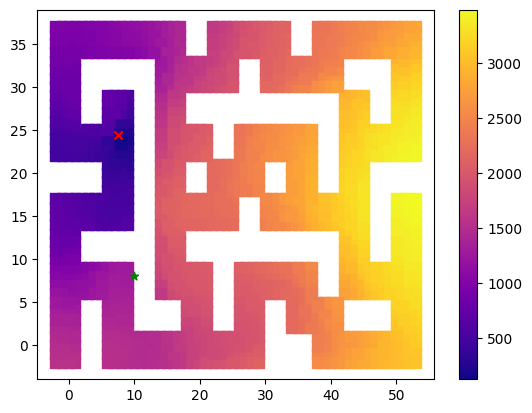

In [24]:
gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, all_cell_points, goal)

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

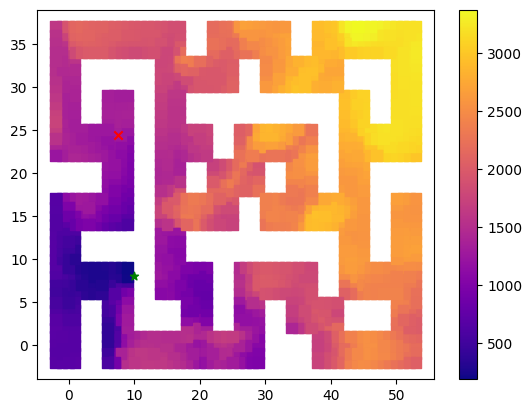

In [25]:
c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_goal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

100%|██████████| 4000000/4000000 [00:26<00:00, 152708.22it/s]


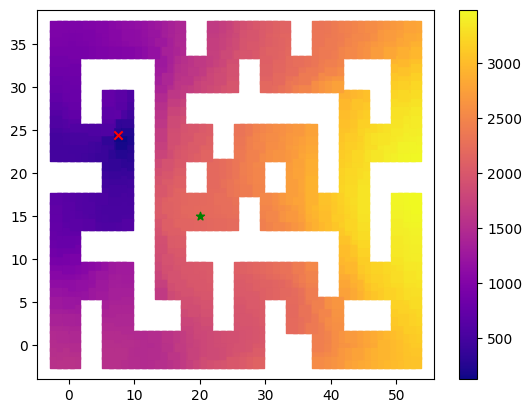

In [26]:
start = np.asarray([11.0, 15.0])
for temp_ob in tqdm(train_dataset.dataset['observations']):
    if np.linalg.norm(temp_ob[:2] - start) < 0.05:
        ob = temp_ob
        break
        # print('no such observation')

goal = np.asarray([20.0, 15.0])

gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, all_cell_points, goal)

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

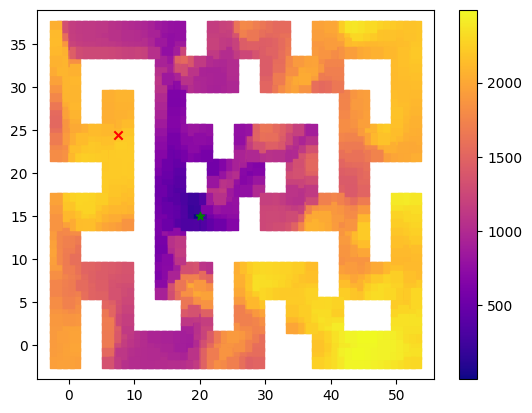

In [27]:
c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_goal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

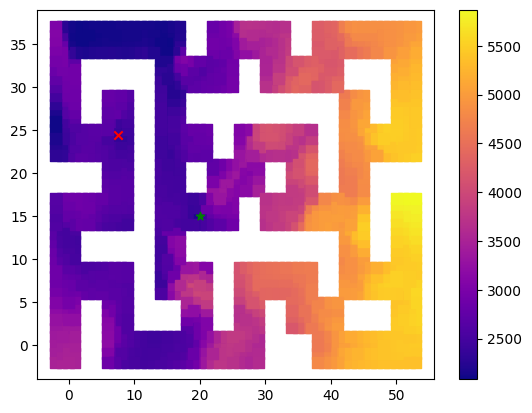

In [28]:
c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal + gamma_to_goal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

In [29]:
ob_to_goal

2180.908878606446

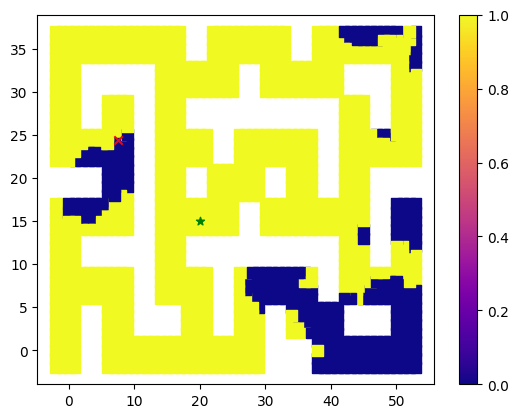

In [30]:
threshold = 0.0

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=(gamma_to_goal) < ob_to_goal + threshold, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

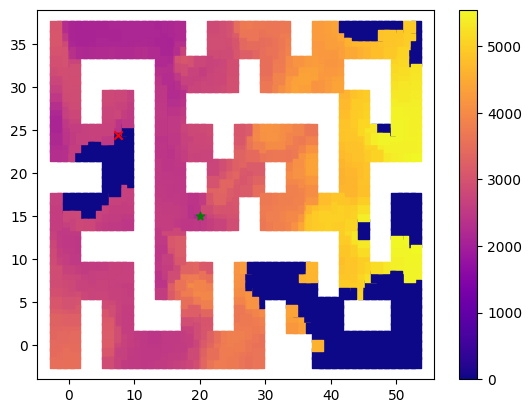

In [31]:
c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=np.where(gamma_to_goal < ob_to_goal, gamma_to_subgoal + gamma_to_goal, -1), cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

In [32]:
print(subgoals.shape)
print(ob.shape)
print(goal.shape)

(128, 2)
(69,)
(2,)


 32%|███▏      | 63/200 [00:11<00:25,  5.44it/s]


no improving subgoal found at step 63


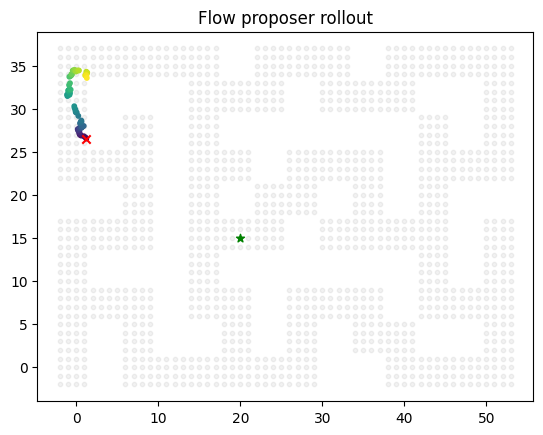

In [33]:
replay_buffer = []
rng = jax.random.PRNGKey(config['seed'])

ob = train_dataset.dataset['observations'][160].copy()
start = ob[:2].copy()

for s in tqdm(range(200)):
    replay_buffer.append(ob[:2].copy())
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

    gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
    gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
    gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
    ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

    mask = gamma_to_goal < ob_to_goal
    if not np.any(mask):
        print(f'no improving subgoal found at step {s}')
        break

    filtered_subgoals = subgoals[mask]
    filtered_scores = (gamma_to_subgoal + gamma_to_goal)[mask]
    subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]

    if np.linalg.norm(subgoal - goal) < 0.005:
        replay_buffer.append(subgoal.copy())
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break

    # Keep the rest of the observation fixed and only move the xy/oracle part.
    # This is only appropriate if the downstream utilities read position from
    # the first two coordinates.
    ob = ob.copy()
    ob[:2] = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

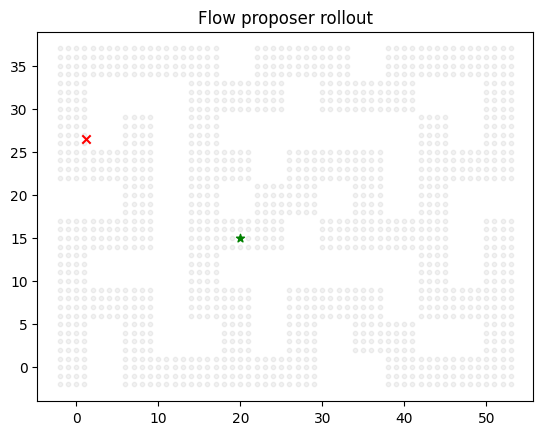

In [34]:
# start = np.asarray([14.0, 15.0])
start_ob = ob.copy()
start_ob[:2] = start

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

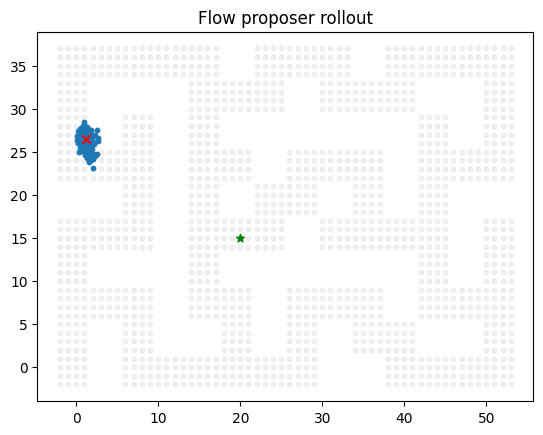

In [35]:
sample_rng, rng = jax.random.split(rng)
subgoals = sample_n(start_ob, goal, 128, sample_rng)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

In [36]:
gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
subgoals = subgoals[gamma_to_goal < ob_to_goal]
print(len(subgoals))

0


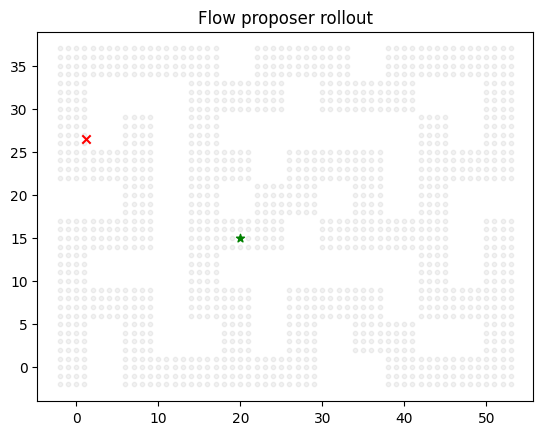

In [37]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

In [38]:
subgoal_idx = np.argmin((gamma_to_subgoal + gamma_to_goal)[gamma_to_goal < ob_to_goal])
subgoal = subgoals[subgoal_idx]

ValueError: attempt to get argmin of an empty sequence

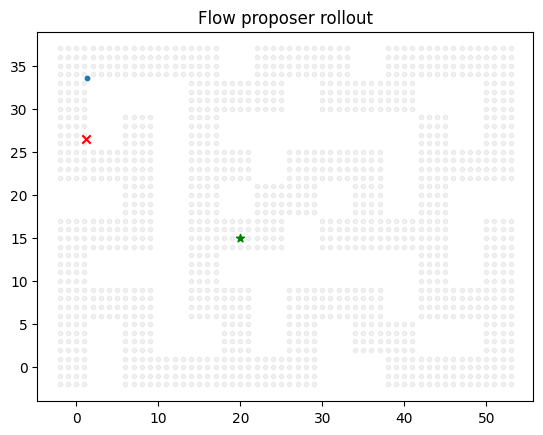

In [39]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoal[0], y=subgoal[1], s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

## How does it look outside of the maze?

In [40]:
print(all_cell_points[..., 0].min())
print(all_cell_points[..., 0].max())
print(all_cell_points[..., 1].min())
print(all_cell_points[..., 1].max())

-2.0
53.0
-2.0
37.0


In [41]:
import numpy as np

x = np.arange(all_cell_points[..., 0].min(), all_cell_points[..., 0].max()+1)
y = np.arange(all_cell_points[..., 1].min(), all_cell_points[..., 1].max()+1)

X, Y = np.meshgrid(x, y)

In [42]:
grid = np.stack([X.ravel(), Y.ravel()], axis=-1)  # shape: (N, 2)
print(grid.shape)

(2240, 2)


In [43]:
ob = train_dataset.dataset['observations'][160].copy()

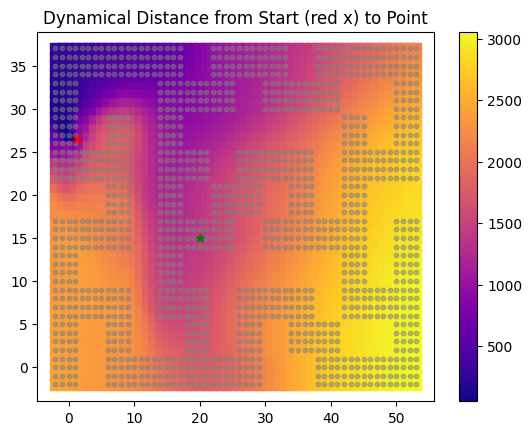

In [44]:
gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, grid, goal)

c = plt.scatter(x=grid[..., 0], y=grid[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal, cmap='plasma')
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.5, c='gray')

plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.title('Dynamical Distance from Start (red x) to Point')
plt.show()


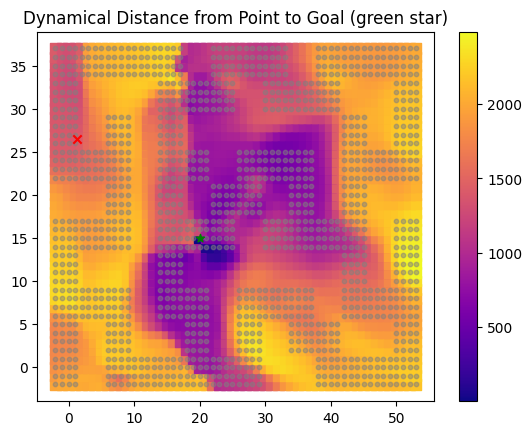

In [45]:
c = plt.scatter(x=grid[..., 0], y=grid[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_goal, cmap='plasma')
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.5, c='gray')

plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.title('Dynamical Distance from Point to Goal (green star)')
plt.show()

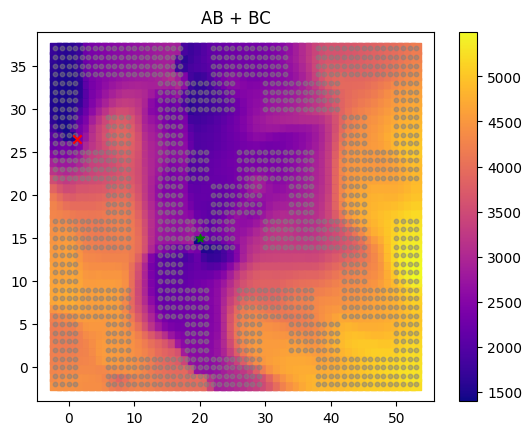

In [46]:
c = plt.scatter(x=grid[..., 0], y=grid[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal + gamma_to_goal, cmap='plasma')
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.5, c='gray')

plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.title('AB + BC')
plt.show()

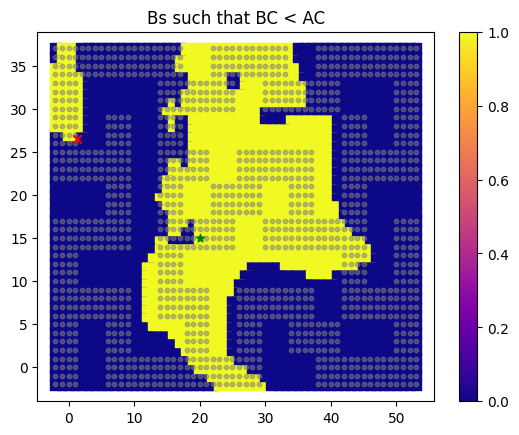

In [47]:
c = plt.scatter(x=grid[..., 0], y=grid[..., 1], s=60, alpha=1.0, marker='s', c=(gamma_to_goal < ob_to_goal), cmap='plasma')
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.5, c='gray')

plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.title('Bs such that BC < AC')
plt.show()

In [48]:
dqc_agent.config['best_of_n']

32

## Testing DQC agent

In [49]:
action_rng, rng = jax.random.split(rng)
dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)

Array([ 0.08111511,  0.10989828,  0.85216546, -0.95574963, -0.39998078,
       -0.5547091 ,  0.91013724,  0.7258717 ,  0.49811587, -0.2698057 ,
       -0.7213297 ,  0.6708595 ,  0.5252766 ,  0.07314281,  0.82826024,
        0.8912757 ,  0.8835652 ,  0.2749161 ,  0.22319962, -0.61309826,
        0.81030697], dtype=float32)

In [50]:
env.spec.id

'humanoidmaze-giant-v0'

In [51]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
ob, _ = env.reset()
start = ob.copy()[:2]
goal = np.asarray([20.0, 15.0])

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:08<00:00, 232.23it/s]


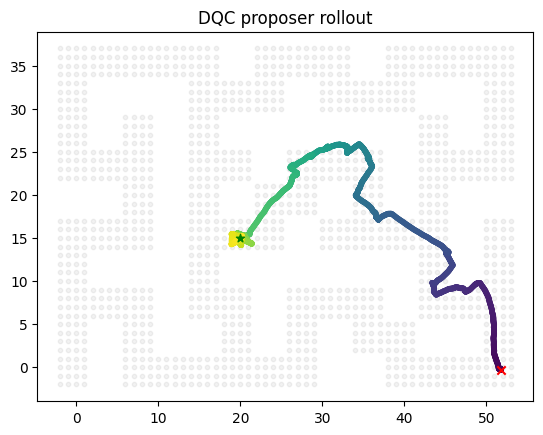

In [52]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('DQC proposer rollout')
plt.show()

In [53]:
goal.shape

(2,)

In [54]:
replay_buffer = []
subgoals_buffer = []

# ob = train_dataset.dataset['observations'][137060].copy()
ob, _ = env.reset()
start = ob.copy()[:2]
goal = np.asarray([20.0, 15.0])
subgoal = None

to_subgoal = 0

for i in tqdm(range(2000)):
    replay_buffer.append(ob)

    if subgoal is None or to_subgoal == 25:
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        # rng, sample_rng = jax.random.split(rng)
        # second_subgoals = flow_agent.sample_actions(subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        # rng, sample_rng = jax.random.split(rng)
        # third_subgoals = flow_agent.sample_actions(second_subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        mask = gamma_to_goal < ob_to_goal
        if not np.any(mask):
            print(f'no improving subgoal found at step {s}')
            break

        filtered_subgoals = subgoals[mask]
        filtered_scores = (gamma_to_subgoal + gamma_to_goal)[mask]
        subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]
        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng)
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None
    
    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

100%|██████████| 2000/2000 [00:29<00:00, 66.78it/s] 


In [55]:
print(len(subgoals_buffer))

124


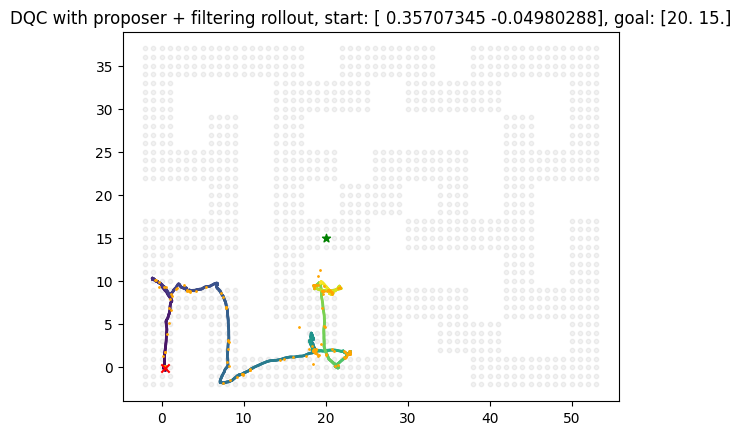

In [56]:
replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout, start: {start}, goal: {goal}')
plt.show()

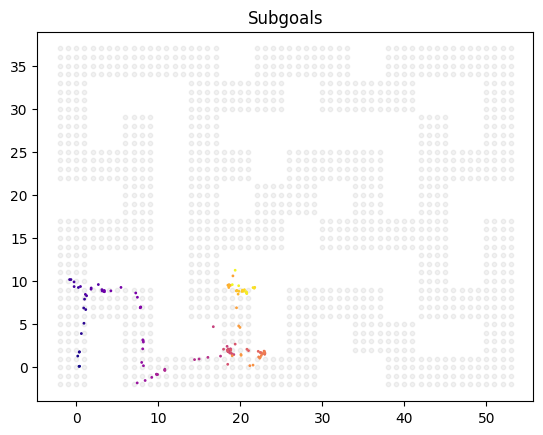

In [57]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c=np.arange(len(subgoals_buffer)), cmap='plasma', s=1)
plt.title('Subgoals')
plt.show()

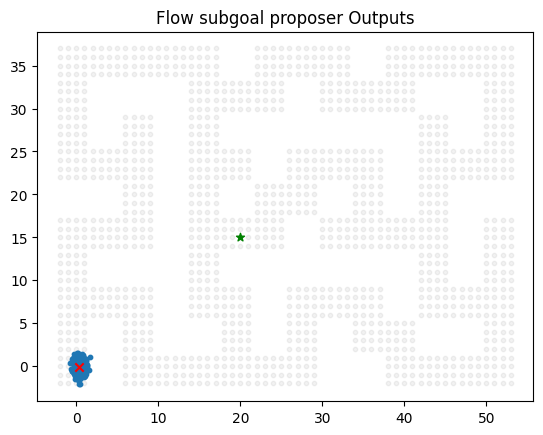

In [58]:
sample_rng, rng = jax.random.split(rng)
subgoals = sample_n(start, goal, 128, sample_rng)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow subgoal proposer Outputs')
plt.show()

0


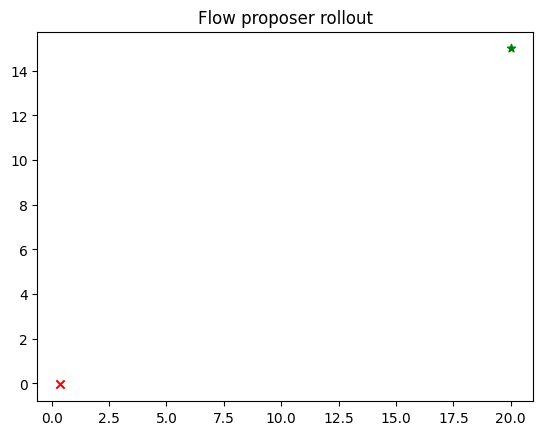

In [59]:
new_ob = ob.copy()
new_ob[0] = 12.5
new_ob[1] = 24.9

gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(new_ob, subgoals, goal)
subgoals = subgoals[gamma_to_goal < ob_to_goal]
print(len(subgoals))

# plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=11, c=(gamma_to_subgoal + gamma_to_goal)[gamma_to_goal < ob_to_goal])
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:08<00:00, 243.58it/s]


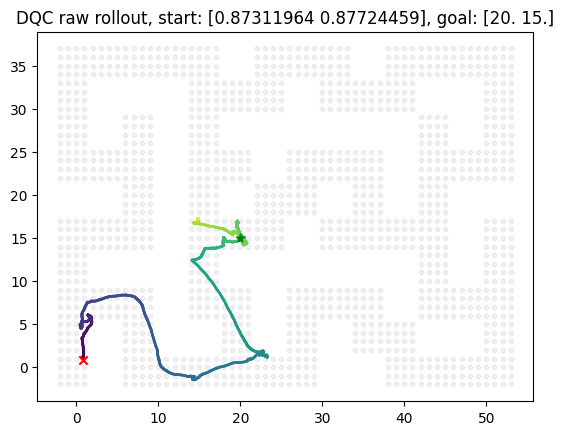

In [60]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
ob, _ = env.reset(options=dict(task_info=dict(
    init_ij = env.unwrapped.xy_to_ij(start),
    goal_ij=env.unwrapped.xy_to_ij(goal)
)))
start = ob.copy()[:2]
# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([20.0, 15.0])

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC raw rollout, start: {start}, goal: {goal}')
plt.show()

## With epsilon randomness

In [61]:
replay_buffer = []
subgoals_buffer = []

ob, _ = env.reset()
start = ob.copy()[:2]
goal = np.asarray([20.0, 15.0])
subgoal = None

to_subgoal = 0

eps = 0.5

for i in tqdm(range(2000)):
    replay_buffer.append(ob)

    if subgoal is None or to_subgoal == 25:
        
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        if np.random.rand() >= eps:

            gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
            gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
            gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
            ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

            mask = gamma_to_goal < ob_to_goal
            if not np.any(mask):
                print(f'no improving subgoal found at step {s}')
                break

            filtered_subgoals = subgoals[mask]
            filtered_scores = (gamma_to_subgoal + gamma_to_goal)[mask]
            subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]

        else:
            subgoal = subgoals[np.random.choice(np.arange(len(subgoals)))]

        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng)
    to_subgoal += 1
    eps = max(0.0, eps * 0.9)
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.05:
        subgoal = None
    
    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:25<00:00, 77.68it/s] 


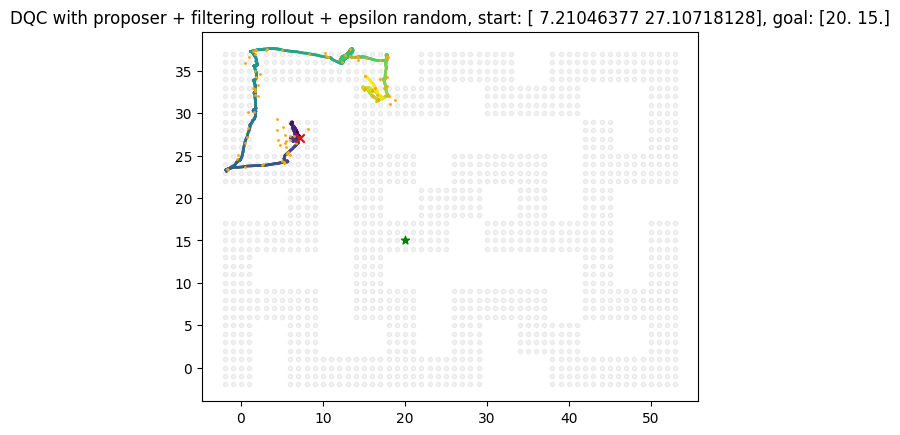

In [62]:
replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout + epsilon random, start: {start}, goal: {goal}')
plt.show()

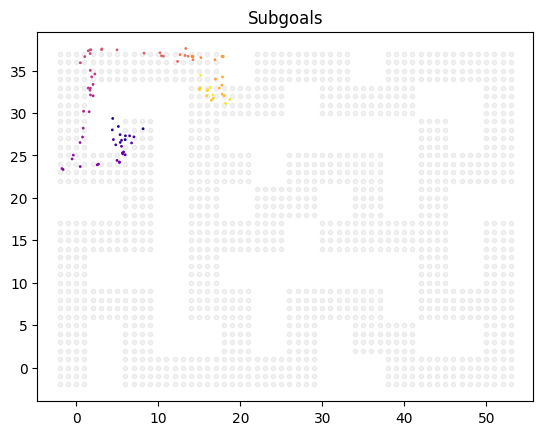

In [63]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c=np.arange(len(subgoals_buffer)), cmap='plasma', s=1)
plt.title('Subgoals')
plt.show()

## With state occupancy

In [64]:
replay_buffer = []
subgoals_buffer = []

ob, _ = env.reset()
start = ob.copy()[:2]
goal = np.asarray([20.0, 15.0])
subgoal = None

to_subgoal = 0

occupancy = {}

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    if (int(ob[0]), int(ob[1])) in occupancy:
        occupancy[(int(ob[0]), int(ob[1]))] += 1
    else:
        occupancy[(int(ob[0]), int(ob[1]))] = 1

    if subgoal is None or to_subgoal == 25:
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        mask = gamma_to_goal < ob_to_goal
        if not np.any(mask):
            print(f'no improving subgoal found at step {s}')
            break

        filtered_subgoals = subgoals[mask]
        filtered_scores = (gamma_to_subgoal + gamma_to_goal)[mask]
        subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]
        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng)
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None
    
    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

100%|██████████| 2000/2000 [00:25<00:00, 77.16it/s] 


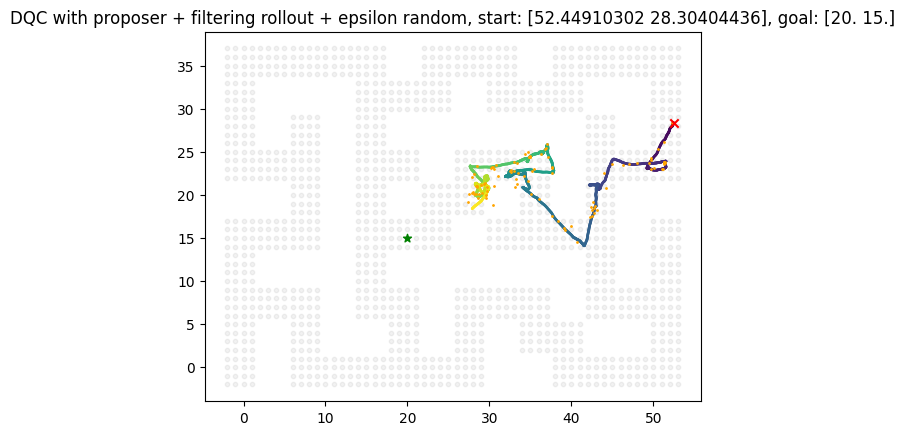

In [65]:
replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout + epsilon random, start: {start}, goal: {goal}')
plt.show()

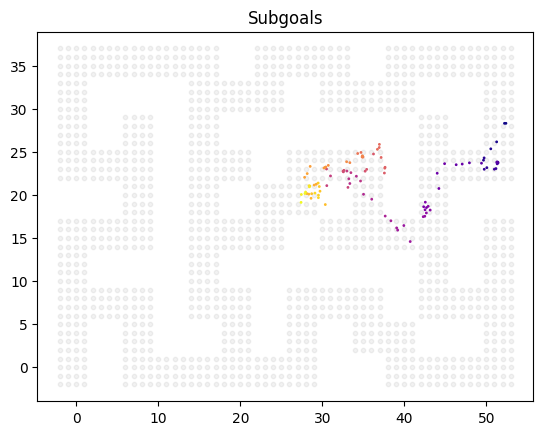

In [66]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c=np.arange(len(subgoals_buffer)), cmap='plasma', s=1)
plt.title('Subgoals')
plt.show()

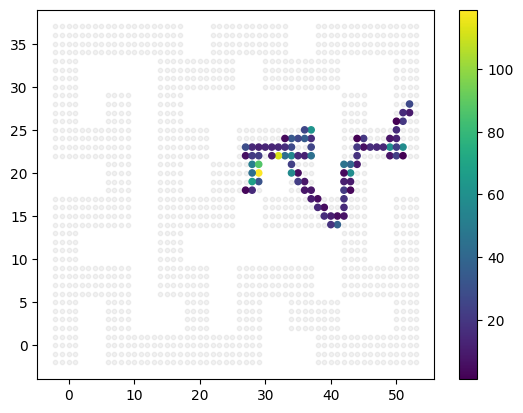

In [67]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
occupancy_xys = np.asarray(list(occupancy.keys()))
occupancy_values = np.asarray(list(occupancy.values()))
c = plt.scatter(x=occupancy_xys[..., 0], y=occupancy_xys[..., 1], c=occupancy_values, s=20)
plt.colorbar(c)
plt.show()

In [68]:
replay_buffer = []
subgoals_buffer = []

ob, _ = env.reset()
start = ob.copy()[:2]
goal = np.asarray([20.0, 15.0])
subgoal = None

to_subgoal = 0

occupancy = {}
beta = 1.0

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    if (int(ob[0]), int(ob[1])) in occupancy:
        occupancy[(int(ob[0]), int(ob[1]))] += 1
    else:
        occupancy[(int(ob[0]), int(ob[1]))] = 1

    if subgoal is None or to_subgoal == 25:
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        mask = gamma_to_goal < ob_to_goal
        if not np.any(mask):
            print(f'no improving subgoal found at step {s}')
            break

        filtered_subgoals = subgoals[mask]
        filtered_scores = (gamma_to_subgoal + gamma_to_goal)[mask]

        for i, xy in enumerate(filtered_subgoals):
            if (int(xy[0]), int(xy[1])) in occupancy:
                filtered_scores[i] = filtered_scores[i] * beta / np.sqrt(occupancy[(int(xy[0]), int(xy[1]))] + 1.0)
            else:
                filtered_scores[i] = filtered_scores[i] * beta / np.sqrt(1.0)

        subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]
        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng)
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None
    
    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:29<00:00, 68.38it/s] 


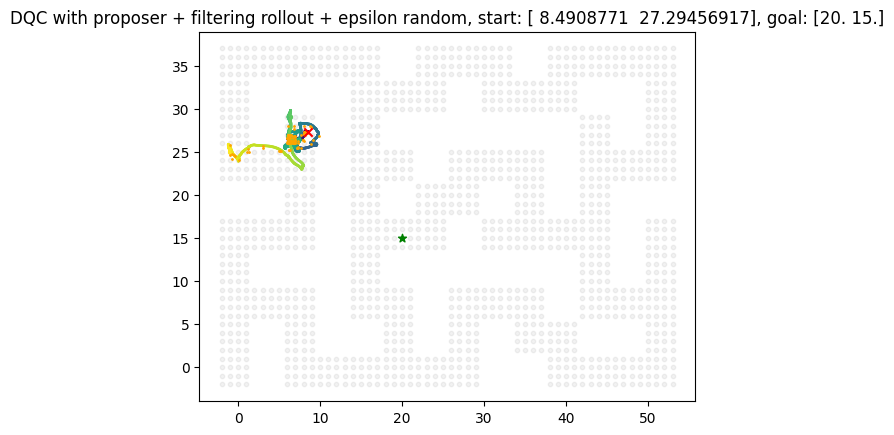

In [69]:
replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout + epsilon random, start: {start}, goal: {goal}')
plt.show()

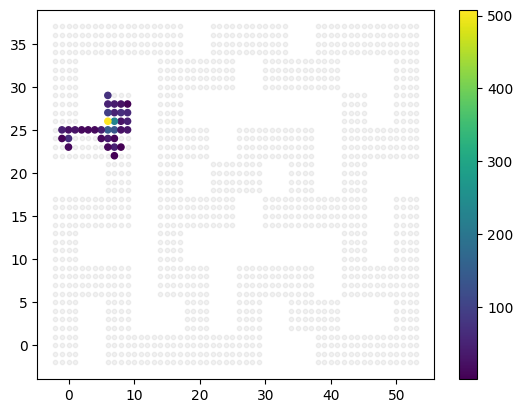

In [70]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
occupancy_xys = np.asarray(list(occupancy.keys()))
occupancy_values = np.asarray(list(occupancy.values()))
c = plt.scatter(x=occupancy_xys[..., 0], y=occupancy_xys[..., 1], c=occupancy_values, s=20)
plt.colorbar(c)
plt.show()

## With RND

In [71]:
import flax
import optax
from utils.flax_utils import TrainState, nonpytree_field

replay_buffer = []
subgoals_buffer = []
rnd_bonus_history = []

ob, _ = env.reset()
start = ob.copy()[:2]
goal = np.asarray([20.0, 15.0])
subgoal = None
to_subgoal = 0
beta = 1.0
rnd_update_freq = 1

obs_min = jnp.asarray(all_cell_points.min(axis=0), dtype=jnp.float32)
obs_max = jnp.asarray(all_cell_points.max(axis=0), dtype=jnp.float32)
obs_center = 0.5 * (obs_min + obs_max)
obs_scale = jnp.maximum(0.5 * (obs_max - obs_min), 1.0)

def add_param_noise(params, rng, scale=1e-3):
    leaves, treedef = jax.tree_util.tree_flatten(params)
    keys = jax.random.split(rng, len(leaves))
    noisy_leaves = [leaf + scale * jax.random.normal(key, leaf.shape, leaf.dtype) for leaf, key in zip(leaves, keys)]
    return jax.tree_util.tree_unflatten(treedef, noisy_leaves)

class StateRND(flax.struct.PyTreeNode):
    rng: any
    predictor: TrainState
    target: TrainState
    coeff: float = nonpytree_field()
    obs_center: any = nonpytree_field()
    obs_scale: any = nonpytree_field()

    @classmethod
    def create(cls, seed, observation_example, hidden_dims=(256, 256, 256), lr=3e-4, coeff=1.0, obs_center=None, obs_scale=None):
        rng = jax.random.PRNGKey(seed)
        rng, target_rng, noise_rng = jax.random.split(rng, 3)
        model = MLP(hidden_dims=hidden_dims, activate_final=False)
        target_params = model.init(target_rng, observation_example)['params']
        pred_params = add_param_noise(target_params, noise_rng, scale=1e-3)
        predictor = TrainState.create(model, pred_params, tx=optax.adam(lr))
        target = TrainState.create(model, target_params, tx=None)
        return cls(
            rng=rng,
            predictor=predictor,
            target=target,
            coeff=coeff,
            obs_center=jnp.asarray(obs_center, dtype=jnp.float32),
            obs_scale=jnp.asarray(obs_scale, dtype=jnp.float32),
        )

    def _normalize_obs(self, observations):
        observations = jnp.asarray(observations, dtype=jnp.float32)
        return (observations - self.obs_center) / self.obs_scale

    def _embed(self, state, params, observations):
        features = state.apply_fn({'params': params}, self._normalize_obs(observations))
        return features / jnp.linalg.norm(features, axis=-1, keepdims=True).clip(1e-8)

    @jax.jit
    def update(self, observations):
        observations = jnp.asarray(observations, dtype=jnp.float32)

        def loss_fn(params):
            pred = self._embed(self.predictor, params, observations)
            target = self._embed(self.target, self.target.params, observations)
            loss = jnp.mean((pred - target) ** 2.0)
            return loss, {'rnd_loss': loss}

        new_predictor, info = self.predictor.apply_loss_fn(loss_fn)
        return self.replace(predictor=new_predictor), info

    @jax.jit
    def get_reward(self, observations):
        observations = jnp.asarray(observations, dtype=jnp.float32)
        pred = self._embed(self.predictor, self.predictor.params, observations)
        target = self._embed(self.target, self.target.params, observations)
        return jnp.mean((pred - target) ** 2.0, axis=-1) * self.coeff

rnd_agent = StateRND.create(
    seed=config['seed'],
    observation_example=jnp.asarray(ob[:2][None], dtype=jnp.float32),
    hidden_dims=(256, 256, 256),
    lr=3e-4,
    coeff=1.0,
    obs_center=obs_center,
    obs_scale=obs_scale,
)


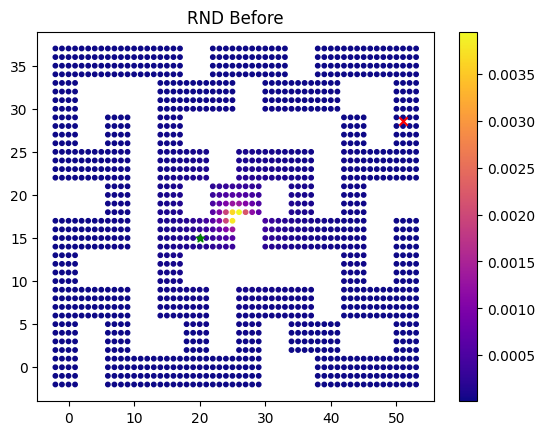

In [72]:
rnd_values = rnd_agent.get_reward(jnp.asarray(all_cell_points, dtype=jnp.float32))

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=1, c=rnd_values, cmap='plasma')
# plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
# plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'RND Before')
plt.colorbar(c)
plt.show()

In [73]:
rng = jax.random.PRNGKey(config['seed'])

for step in tqdm(range(2000)):
    replay_buffer.append(ob.copy())

    # if step % rnd_update_freq == 0:
    #     rnd_agent, rnd_info = rnd_agent.update(jnp.asarray(ob[:2][None], dtype=jnp.float32))

    if subgoal is None or to_subgoal == 25:
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        mask = gamma_to_goal < ob_to_goal
        if not np.any(mask):
            print(f'no improving subgoal found at step {step}')
            break

        filtered_subgoals = subgoals[mask]
        filtered_scores = (gamma_to_subgoal + gamma_to_goal)[mask]

        rnd_bonus = np.asarray(
            rnd_agent.get_reward(jnp.asarray(filtered_subgoals, dtype=jnp.float32))
        ).reshape(-1)
        rnd_bonus_history.append(rnd_bonus)

        adjusted_scores = filtered_scores - beta * rnd_bonus
        subgoal = filtered_subgoals[int(np.argmin(adjusted_scores))]
        rnd_agent, rnd_info = rnd_agent.update(jnp.asarray(subgoal[None], dtype=jnp.float32))
        print(rnd_info['rnd_loss'])
        subgoals_buffer.append(subgoal.copy())
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = np.asarray(dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng))
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None

    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

  0%|          | 1/2000 [00:02<1:13:05,  2.19s/it]

1.2476302e-05


  0%|          | 2/2000 [00:02<44:50,  1.35s/it]  

5.5860342e-05


  1%|▏         | 26/2000 [00:03<02:23, 13.78it/s]

...

2.424957e-06


 99%|█████████▉| 1988/2000 [01:15<00:00, 74.60it/s]

6.29998e-07


100%|██████████| 2000/2000 [01:15<00:00, 26.52it/s]

5.5191356e-07


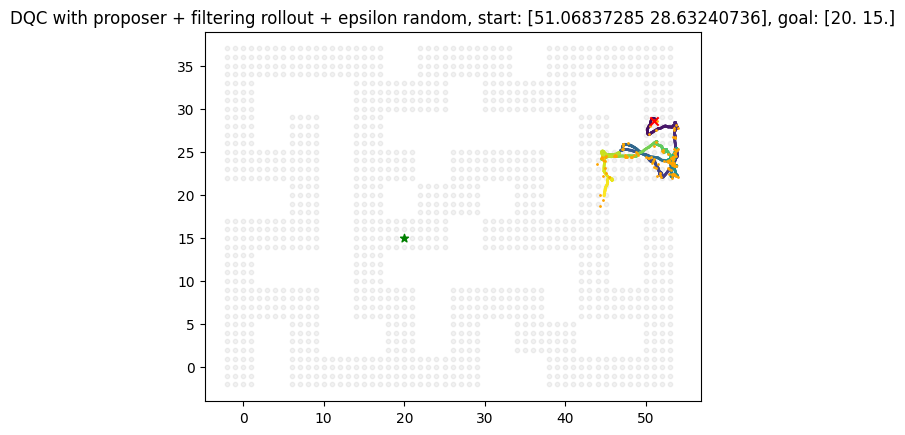

In [74]:
replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout + epsilon random, start: {start}, goal: {goal}')
plt.show()

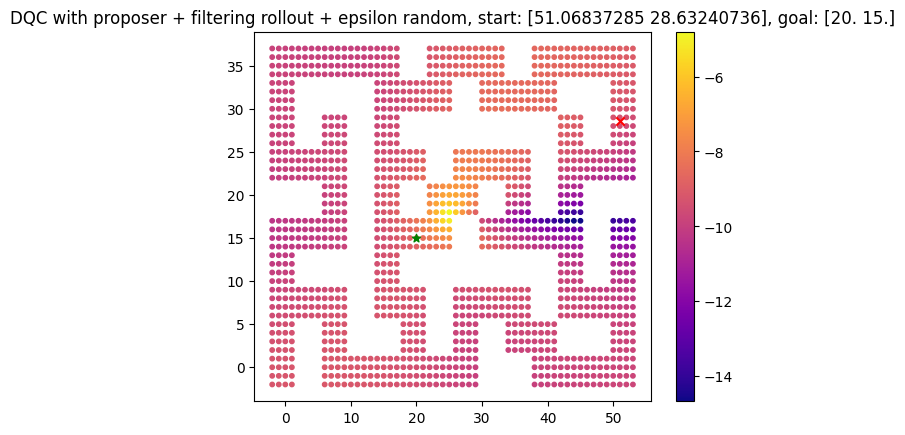

In [75]:
rnd_values = np.log(rnd_agent.get_reward(jnp.asarray(all_cell_points, dtype=jnp.float32)))

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=1, c=rnd_values, cmap='plasma')
# plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
# plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout + epsilon random, start: {start}, goal: {goal}')
plt.colorbar(c)
plt.show()

## Without argmin

In [ ]:
replay_buffer = []
subgoals_buffer = []

# ob = train_dataset.dataset['observations'][137060].copy()
ob, _ = env.reset()
start = ob.copy()[:2]
goal = np.asarray([20.0, 15.0])
subgoal = None

to_subgoal = 0

for i in tqdm(range(2000)):
    replay_buffer.append(ob)

    if subgoal is None or to_subgoal == 25:
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        # rng, sample_rng = jax.random.split(rng)
        # second_subgoals = flow_agent.sample_actions(subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        # rng, sample_rng = jax.random.split(rng)
        # third_subgoals = flow_agent.sample_actions(second_subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        mask = gamma_to_goal < ob_to_goal
        if not np.any(mask):
            print(f'no improving subgoal found at step {s}')
            break

        filtered_subgoals = subgoals[mask]
        # filtered_scores = (gamma_to_subgoal + gamma_to_goal)[mask]
        # subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]
        subgoal_idx = np.random.choice(np.arange(len(filtered_subgoals)))
        subgoal = filtered_subgoals[subgoal_idx]
        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng)
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None
    
    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:22<00:00, 88.57it/s] 


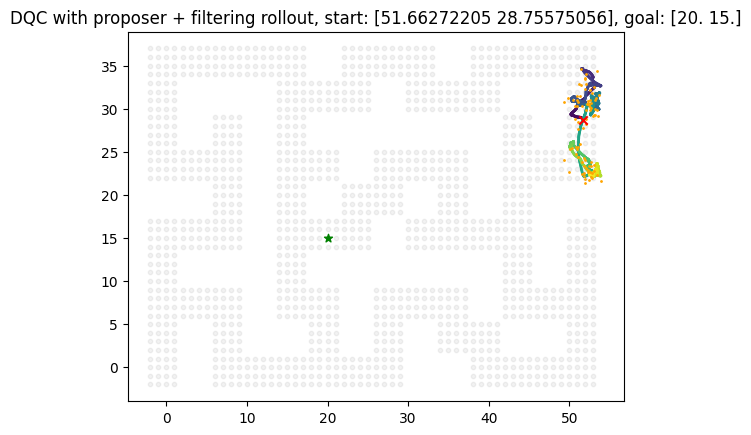

In [77]:
replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout, start: {start}, goal: {goal}')
plt.show()

100%|██████████| 2000/2000 [00:08<00:00, 244.47it/s]


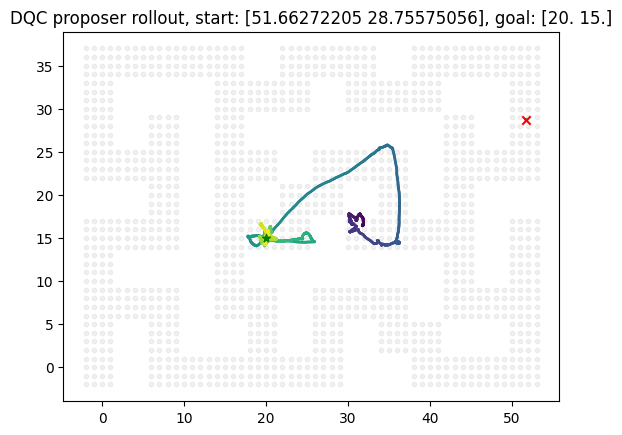

In [78]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
ob, _ = env.reset()
# start = ob.copy()[:2]
ob[..., :2] = start.copy()
# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([20.0, 15.0])

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

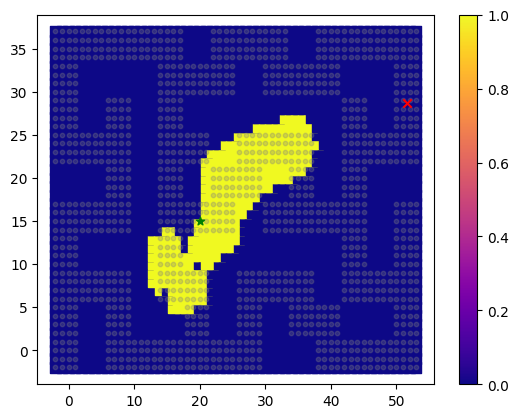

In [79]:
threshold = 0.0
gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, grid, goal)



c = plt.scatter(x=grid[..., 0], y=grid[..., 1], s=60, alpha=1.0, marker='s', c=(gamma_to_goal) < ob_to_goal + threshold, cmap='plasma')
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.3, c='gray')
plt.scatter(x=start[0], y=start[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

## Crippling the agent

In [80]:
dqc_agent.config['best_of_n']

32

100%|██████████| 4000/4000 [00:16<00:00, 240.77it/s]


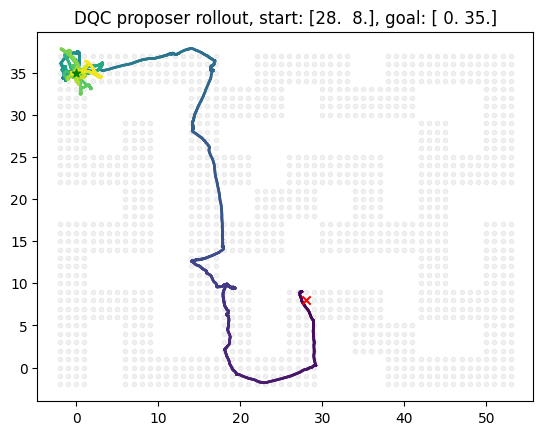

In [81]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
# ob, _ = env.reset()
# start = ob.copy()[:2]
# ob[..., :2] = start.copy()
start = np.asarray([28.0, 8.0])
goal = np.asarray([0.0, 35.0])
# ob[:2] = start.copy()
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

for i in tqdm(range(4000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

100%|██████████| 4000/4000 [00:22<00:00, 176.29it/s]


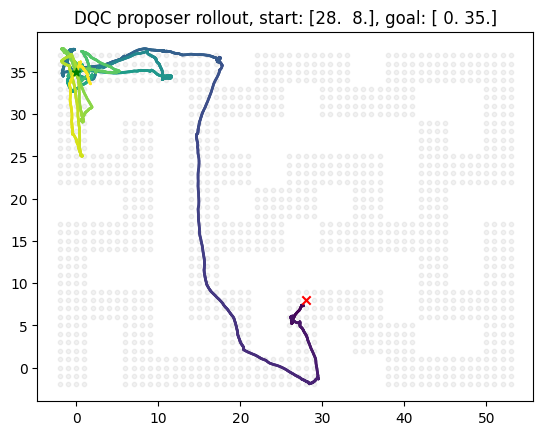

In [82]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
# ob, _ = env.reset()
# start = ob.copy()[:2]
# ob[..., :2] = start.copy()
start = np.asarray([28.0, 8.0])
goal = np.asarray([0.0, 35.0])
# ob[:2] = start.copy()
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

for i in tqdm(range(4000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng, best_of_n_override=4)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [00:21<00:00, 183.30it/s]


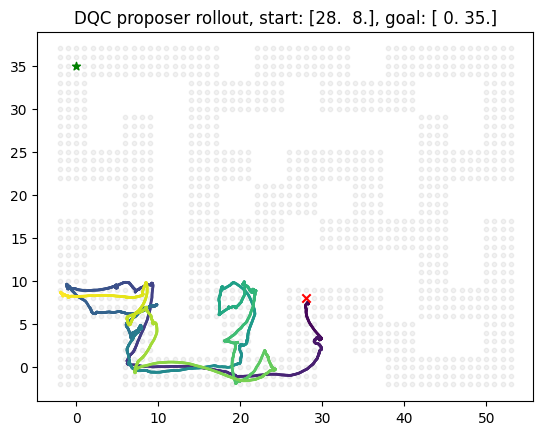

In [83]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
# ob, _ = env.reset()
# start = ob.copy()[:2]
# ob[..., :2] = start.copy()
start = np.asarray([28.0, 8.0])
goal = np.asarray([0.0, 35.0])
# ob[:2] = start.copy()
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

for i in tqdm(range(4000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng, best_of_n_override=2)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

100%|██████████| 4000/4000 [00:16<00:00, 236.97it/s]


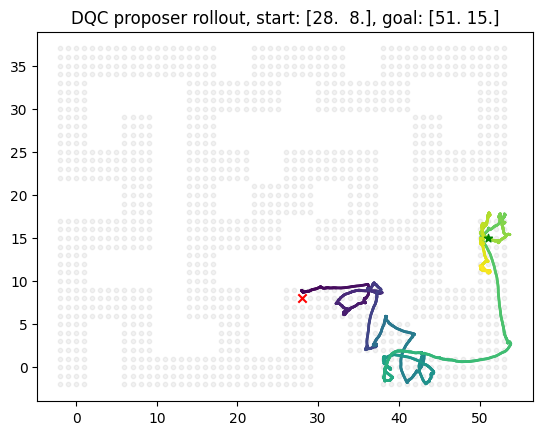

In [84]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
# ob, _ = env.reset()
# start = ob.copy()[:2]
# ob[..., :2] = start.copy()
start = np.asarray([28.0, 8.0])
goal = np.asarray([51.0, 15.0])
# ob[:2] = start.copy()
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

for i in tqdm(range(4000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng, best_of_n_override=2)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [00:14<00:00, 267.79it/s]


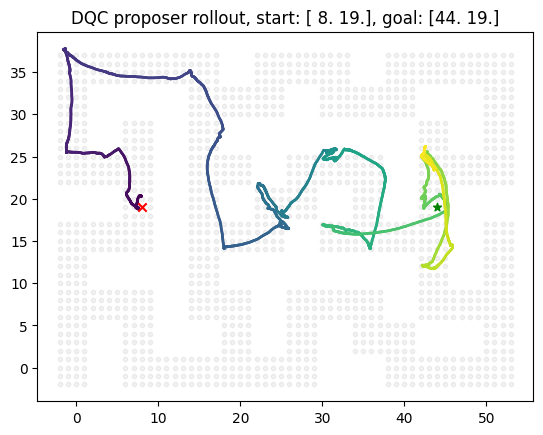

In [89]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
# ob, _ = env.reset()
# start = ob.copy()[:2]
# ob[..., :2] = start.copy()
start = np.asarray([8.0, 19.0])
goal = np.asarray([44.0, 19.0])
# ob[:2] = start.copy()
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

for i in tqdm(range(4000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng, best_of_n_override=2)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

In [90]:
dqc_agent.config

FrozenDict({
    action_dim: 21,
    actor_hidden_dims: [1024, 1024, 1024, 1024],
    actor_layer_norm: True,
    agent_name: 'dqc',
    backup_horizon: 25,
    batch_size: 4096,
    best_of_n: 32,
    dataset_class: 'CGCDataset',
    discount: 0.999,
    distill_method: 'expectile',
    flow_steps: 10,
    implicit_backup_type: 'quantile',
    kappa_b: 0.5,
    kappa_d: 0.5,
    layer_norm: True,
    lr: 0.0003,
    num_qs: 2,
    ob_dims: (69,),
    policy_chunk_size: 1,
    q_agg: 'mean',
    tau: 0.005,
    use_chunk_critic: False,
    value_geom_sample: False,
    value_hidden_dims: [1024, 1024, 1024, 1024],
    value_p_curgoal: 0.2,
    value_p_randomgoal: 0.3,
    value_p_trajgoal: 0.5,
    train_goal_proposer: False,
    ac_action_dim: 21,
    goal_dim: 2,
})